# Representations multi-echelles du dataset Rayleigh--Taylor

Objectif: proposer plusieurs visualisations complementaires montrant que les champs de densite RT-CEA sont hautement multi-echelles.

Le notebook est volontairement leger: par defaut il ne lit qu'un petit sous-ensemble contigu du fichier HDF5. Les traitements couteux sur tout le dataset sont evites. Les indices et le nombre de snapshots peuvent etre modifies dans la cellule de parametres.

Representations proposees:
- champ physique et coupes 1D;
- module de la transformee de Fourier 2D;
- spectre d'energie radial moyen;
- decomposition en ondelettes 2D par sous-bandes;
- energie par niveau d'ondelettes;
- reconstructions Fourier par bandes d'echelles;
- comparaison statistique sur quelques snapshots.

Chaque diagnostic est compare avec `image.jpeg`, une image naturelle du meme dossier, afin de distinguer les signatures multi-echelles propres au champ RT d'une image naturelle classique.


In [1]:
import os
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pywt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from lib.cea_lib.signal2D import normalize2d, mask2d, resize2d
from lib.cea_lib.physic import taille_zone_melange

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "image.cmap": "RdYlBu_r",
})


## Parametres legers

`START_INDEX` et `MAX_SNAPSHOTS` controlent la quantite de donnees lue depuis le HDF5. Les cellules ci-dessous ne chargent pas tout le dataset.

In [2]:
DATA_FILE = project_root / "data" / "RTCEA_bimode.hdf5"
IMAGE_FILE = Path.cwd() / "image.jpeg"

START_INDEX = 100
MAX_SNAPSHOTS = 20
DISPLAY_RESIZE = 256
WAVELET = "sym6"
WAVELET_LEVEL = 3

print(DATA_FILE)
print(IMAGE_FILE)


/home/chapuissamuel/Documents/code/RT-Diffusion/data/RTCEA_bimode.hdf5
/home/chapuissamuel/Documents/code/RT-Diffusion/analyse_outils/image.jpeg


In [3]:
def describe_hdf5(path):
    with h5py.File(path, "r") as f:
        for key in f.keys():
            dset = f[key]
            print(f"{key}: shape={dset.shape}, dtype={dset.dtype}")
            for attr_name, attr_value in dset.attrs.items():
                print(f"  {attr_name}: {attr_value}")


def load_rtcea_slice(path, start=0, count=20):
    """Lit uniquement une tranche contigue du fichier RT-CEA."""
    with h5py.File(path, "r") as f:
        stop = min(start + count, f["data"].shape[0])
        data = f["data"][start:stop].astype(np.float32)
        labels = f["labels"][start:stop].astype(np.float32)

    # Convention utilisee par load_RTCEA dans lib/cea_lib/data_loader.py.
    data = data[:, ::-1, :]
    return data, labels


def preprocess_one(x, resize=256):
    """Normalisation + crop central, proche de data_preprocessing mais applique a un seul champ."""
    x = normalize2d(x)
    cropped = mask2d(x, x.shape[0] // 2, x.shape[0] // 2, crop=True)
    if resize is not None and resize > 0 and cropped.shape != (resize, resize):
        try:
            cropped = resize2d(cropped, resize, resize)
        except ImportError:
            y_idx = np.linspace(0, cropped.shape[0] - 1, resize).round().astype(int)
            x_idx = np.linspace(0, cropped.shape[1] - 1, resize).round().astype(int)
            cropped = cropped[np.ix_(y_idx, x_idx)]
    return cropped


def resize_nearest(x, shape):
    y_idx = np.linspace(0, x.shape[0] - 1, shape[0]).round().astype(int)
    x_idx = np.linspace(0, x.shape[1] - 1, shape[1]).round().astype(int)
    return x[np.ix_(y_idx, x_idx)]


def load_natural_image(path, shape=(256, 256)):
    """Charge image.jpeg, convertit en luminance et normalise entre 0 et 1."""
    img = plt.imread(path).astype(np.float32)
    if img.max() > 1:
        img = img / 255.0
    if img.ndim == 3:
        img = img[..., :3]
        img = 0.2126 * img[..., 0] + 0.7152 * img[..., 1] + 0.0722 * img[..., 2]
    return normalize2d(resize_nearest(img, shape))


describe_hdf5(DATA_FILE)
raw_data, labels = load_rtcea_slice(DATA_FILE, START_INDEX, MAX_SNAPSHOTS)
data = np.stack([preprocess_one(x, DISPLAY_RESIZE) for x in raw_data])
natural_image = load_natural_image(IMAGE_FILE, shape=data[0].shape)

label_names = [
    "Atwood", "time", "mixing_size", "time_star", "mixing_size_star",
    "mixing_size_perc", "phase", "nb_modes"
]
print("raw_data:", raw_data.shape, raw_data.dtype)
print("processed data:", data.shape, data.dtype)
print("natural_image:", natural_image.shape, natural_image.dtype)
print("labels:", labels.shape)


data: shape=(1978, 512, 256), dtype=float32
  fields_names: ['density']
labels: shape=(1978, 8), dtype=float32
  labels_names: ['Atwood' 'time' 'mixing_size' 'time_star' 'mixing_size_star'
 'mixing_size_perc' 'phase' 'nb_modes']
raw_data: (20, 512, 256) float32
processed data: (20, 256, 256) float32
natural_image: (256, 256) float32
labels: (20, 8)


## 1. Champ physique et coupes 1D

La signature multi-echelle est deja visible dans l'espace physique: interface globale, bulles/spikes, et fluctuations fines dans la zone de melange. Les coupes horizontale et verticale montrent que plusieurs longueurs caracteristiques coexistent dans un meme snapshot.

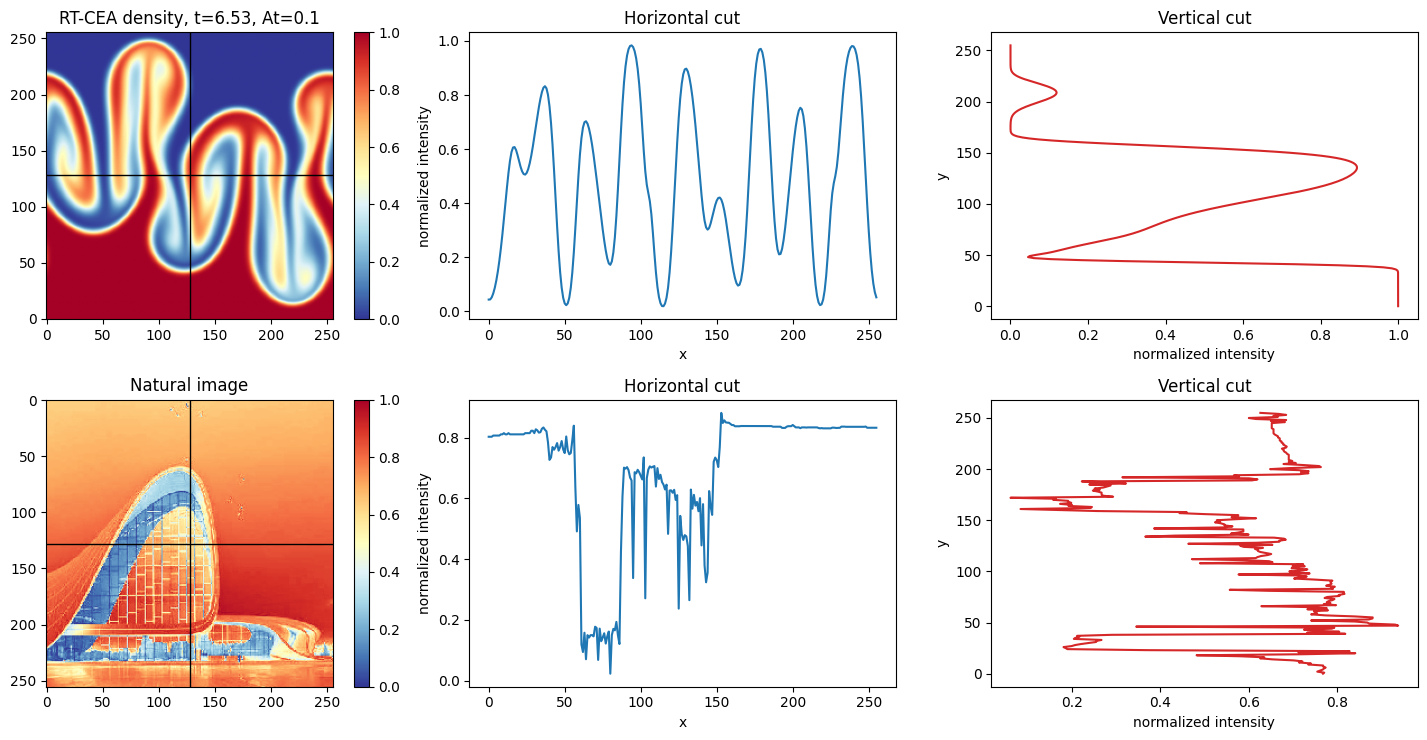

In [4]:
sample_id = min(5, len(data) - 1)
x = data[sample_id]
lab = labels[sample_id]
comparison_images = [("RT-CEA density", x), ("Natural image", natural_image)]
display_origins = {"RT-CEA density": "lower", "Natural image": "upper"}

fig, ax = plt.subplots(len(comparison_images), 3, figsize=(15, 7.5))
for row, (name, img) in enumerate(comparison_images):
    mid_y = img.shape[0] // 2
    mid_x = img.shape[1] // 2
    origin = display_origins[name]
    im = ax[row, 0].imshow(img, origin=origin, aspect="equal")
    ax[row, 0].axhline(mid_y, color="black", lw=1)
    ax[row, 0].axvline(mid_x, color="black", lw=1)
    title = f"{name}, t={lab[1]:.3g}, At={lab[0]:.3g}" if row == 0 else name
    ax[row, 0].set_title(title)
    fig.colorbar(im, ax=ax[row, 0], fraction=0.046)

    ax[row, 1].plot(img[mid_y, :], color="tab:blue")
    ax[row, 1].set_title("Horizontal cut")
    ax[row, 1].set_xlabel("x")
    ax[row, 1].set_ylabel("normalized intensity")

    y_axis = np.arange(img.shape[0]) if origin == "lower" else np.arange(img.shape[0] - 1, -1, -1)
    ax[row, 2].plot(img[:, mid_x], y_axis, color="tab:red")
    ax[row, 2].set_title("Vertical cut")
    ax[row, 2].set_xlabel("normalized intensity")
    ax[row, 2].set_ylabel("y")

plt.tight_layout()
plt.show()


## 2. Transformee de Fourier 2D

Le module de la FFT met en evidence la repartition de l'energie sur les nombres d'onde. Une instabilite strictement mono-echelle produirait une concentration etroite autour de quelques modes. Ici, la presence simultanee d'energie pres de l'origine et loin de l'origine indique la coexistence de grandes structures et de fluctuations plus fines.

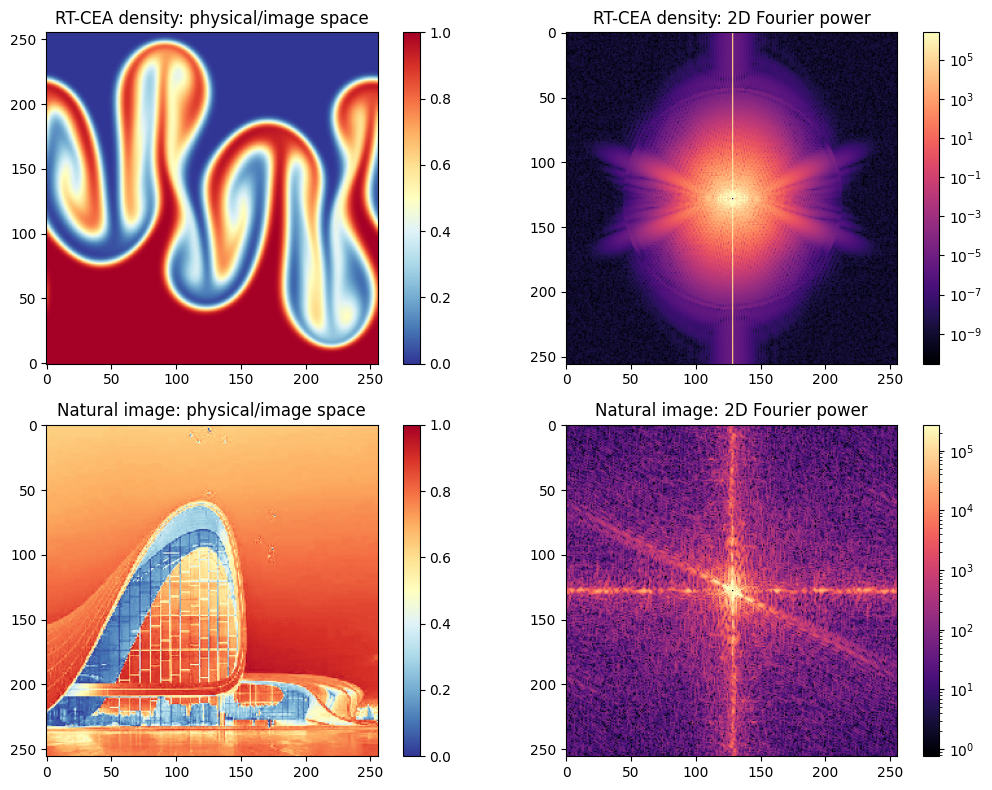

In [5]:
def fft2_power(x):
    xc = x - np.mean(x)
    F = np.fft.fftshift(np.fft.fft2(xc))
    return np.abs(F) ** 2


fig, ax = plt.subplots(len(comparison_images), 2, figsize=(11, 8))
for row, (name, img) in enumerate(comparison_images):
    P = fft2_power(img)
    im0 = ax[row, 0].imshow(img, origin=display_origins[name], aspect="equal")
    ax[row, 0].set_title(f"{name}: physical/image space")
    fig.colorbar(im0, ax=ax[row, 0], fraction=0.046)

    positive = P[P > 0]
    im1 = ax[row, 1].imshow(
        P,
        origin="upper",
        norm=LogNorm(vmin=np.percentile(positive, 1), vmax=np.percentile(positive, 99.9)),
        cmap="magma",
    )
    ax[row, 1].set_title(f"{name}: 2D Fourier power")
    fig.colorbar(im1, ax=ax[row, 1], fraction=0.046)

plt.tight_layout()
plt.show()


## 3. Spectre radial d'energie

Le spectre radial reduit la FFT 2D en une courbe $E(k)$. Ce n'est pas un spectre turbulent isotrope au sens strict, car la RTI est anisotrope et inhomogene verticalement. Il reste neanmoins utile comme diagnostic compact de la largeur de bande: plus la plage de nombres d'onde portant de l'energie est large, plus la representation doit capturer des echelles variees.

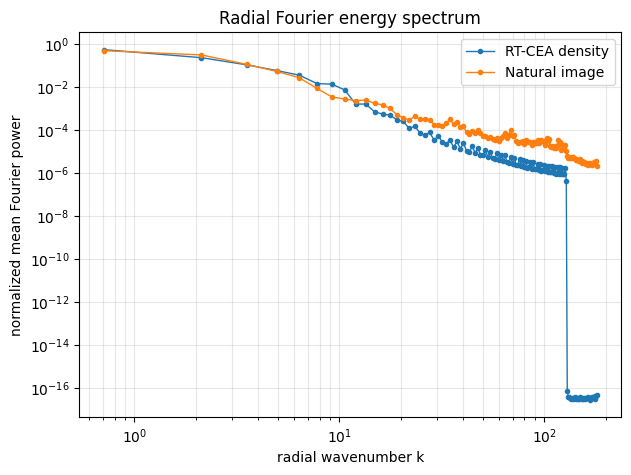

In [6]:
def radial_power_spectrum(x, nbins=None):
    P = fft2_power(x)
    ny, nx = x.shape
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    KX, KY = np.meshgrid(kx, ky)
    kr = np.sqrt(KX ** 2 + KY ** 2)

    if nbins is None:
        nbins = min(nx, ny) // 2
    edges = np.linspace(0, kr.max(), nbins + 1)
    kvals = 0.5 * (edges[:-1] + edges[1:])
    E = np.zeros(nbins)
    counts = np.zeros(nbins)

    bins = np.digitize(kr.ravel(), edges) - 1
    valid = (bins >= 0) & (bins < nbins)
    np.add.at(E, bins[valid], P.ravel()[valid])
    np.add.at(counts, bins[valid], 1)
    E = np.divide(E, counts, out=np.zeros_like(E), where=counts > 0)
    return kvals, E


plt.figure(figsize=(7, 5))
for name, img in comparison_images:
    k, E = radial_power_spectrum(img)
    valid = (k > 0) & (E > 0)
    plt.loglog(k[valid], E[valid] / E[valid].sum(), marker=".", lw=1, label=name)

plt.xlabel("radial wavenumber k")
plt.ylabel("normalized mean Fourier power")
plt.title("Radial Fourier energy spectrum")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


## 4. Decomposition en ondelettes 2D

Les ondelettes separent explicitement approximation grossiere et details orientes. Pour un niveau $j$, les sous-bandes $LH_j$, $HL_j$, $HH_j$ isolent respectivement des variations verticales, horizontales et diagonales. Cette representation est adaptee au caractere localise et intermittent de la zone de melange.

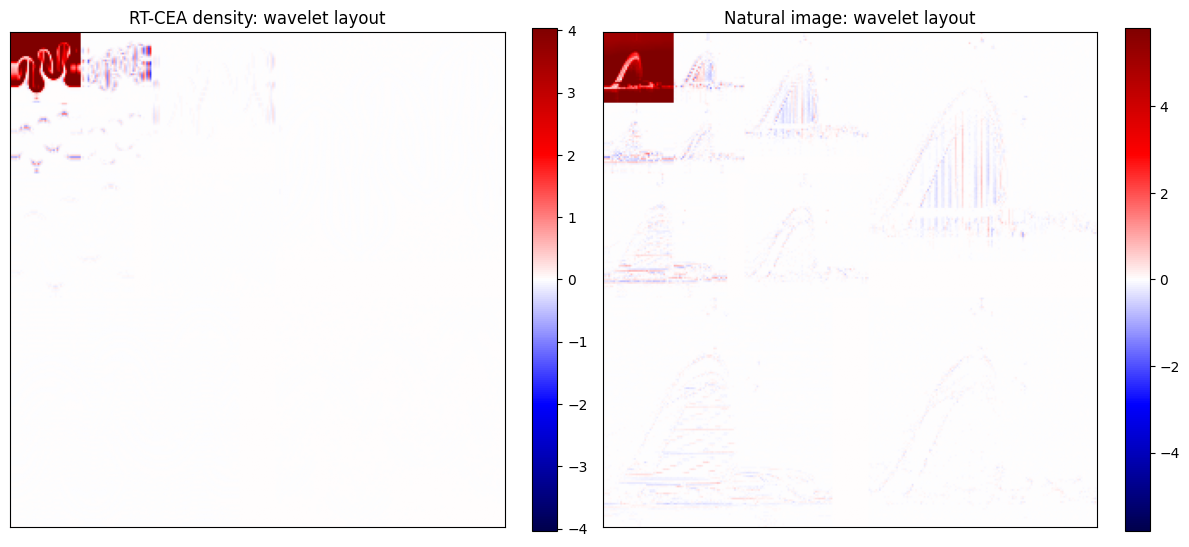

In [7]:
def plot_wavelet_subbands(x, wavelet="sym6", level=3, title=None, ax=None):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level)
    arr, _ = pywt.coeffs_to_array(coeffs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    else:
        fig = ax.figure
    vmax = np.percentile(np.abs(arr), 99)
    im = ax.imshow(arr, cmap="seismic", vmin=-vmax, vmax=vmax, origin="upper")
    ax.set_title(title or f"Wavelet coefficient layout ({wavelet}, level={level})")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
    return arr


fig, ax = plt.subplots(1, len(comparison_images), figsize=(12, 5.5))
for a, (name, img) in zip(ax, comparison_images):
    plot_wavelet_subbands(img, WAVELET, WAVELET_LEVEL, title=f"{name}: wavelet layout", ax=a)
plt.tight_layout()
plt.show()


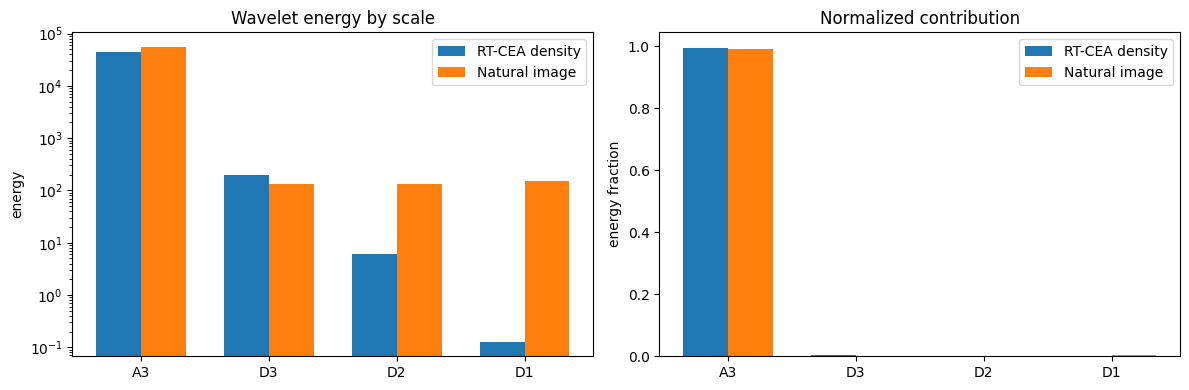

RT-CEA density
  A3: energy=4.4927e+04, fraction=99.544%
  D3: energy=1.9939e+02, fraction=0.442%
  D2: energy=6.0977e+00, fraction=0.014%
  D1: energy=1.2887e-01, fraction=0.000%
Natural image
  A3: energy=5.5100e+04, fraction=99.249%
  D3: energy=1.3483e+02, fraction=0.243%
  D2: energy=1.2993e+02, fraction=0.234%
  D1: energy=1.5207e+02, fraction=0.274%


In [8]:
def wavelet_energy_by_level(x, wavelet="sym6", level=3):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level)
    energies = [np.sum(coeffs[0] ** 2)]
    names = [f"A{level}"]
    for ell, detail in zip(range(level, 0, -1), coeffs[1:]):
        cH, cV, cD = detail
        energies.append(np.sum(cH ** 2) + np.sum(cV ** 2) + np.sum(cD ** 2))
        names.append(f"D{ell}")
    energies = np.asarray(energies)
    return names, energies


energy_data = {}
for image_name, img in comparison_images:
    names, energies = wavelet_energy_by_level(img, WAVELET, WAVELET_LEVEL)
    energy_data[image_name] = (energies, energies / energies.sum())

positions = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for offset, (image_name, (energies, fractions)) in zip([-width / 2, width / 2], energy_data.items()):
    ax[0].bar(positions + offset, energies, width=width, label=image_name)
    ax[1].bar(positions + offset, fractions, width=width, label=image_name)

ax[0].set_yscale("log")
ax[0].set_ylabel("energy")
ax[0].set_title("Wavelet energy by scale")
ax[0].set_xticks(positions, names)
ax[0].legend()

ax[1].set_ylabel("energy fraction")
ax[1].set_title("Normalized contribution")
ax[1].set_xticks(positions, names)
ax[1].legend()

plt.tight_layout()
plt.show()

for image_name, (energies, fractions) in energy_data.items():
    print(image_name)
    for name, e, frac in zip(names, energies, fractions):
        print(f"  {name}: energy={e:.4e}, fraction={frac:.3%}")


## 5. Reconstruction par echelle Fourier

Cette cellule isole des anneaux de nombres d'onde. Les petites valeurs de $k$ reconstruisent les grandes structures de la zone de melange, tandis que les anneaux plus eleves extraient les interfaces fines et les fluctuations locales.

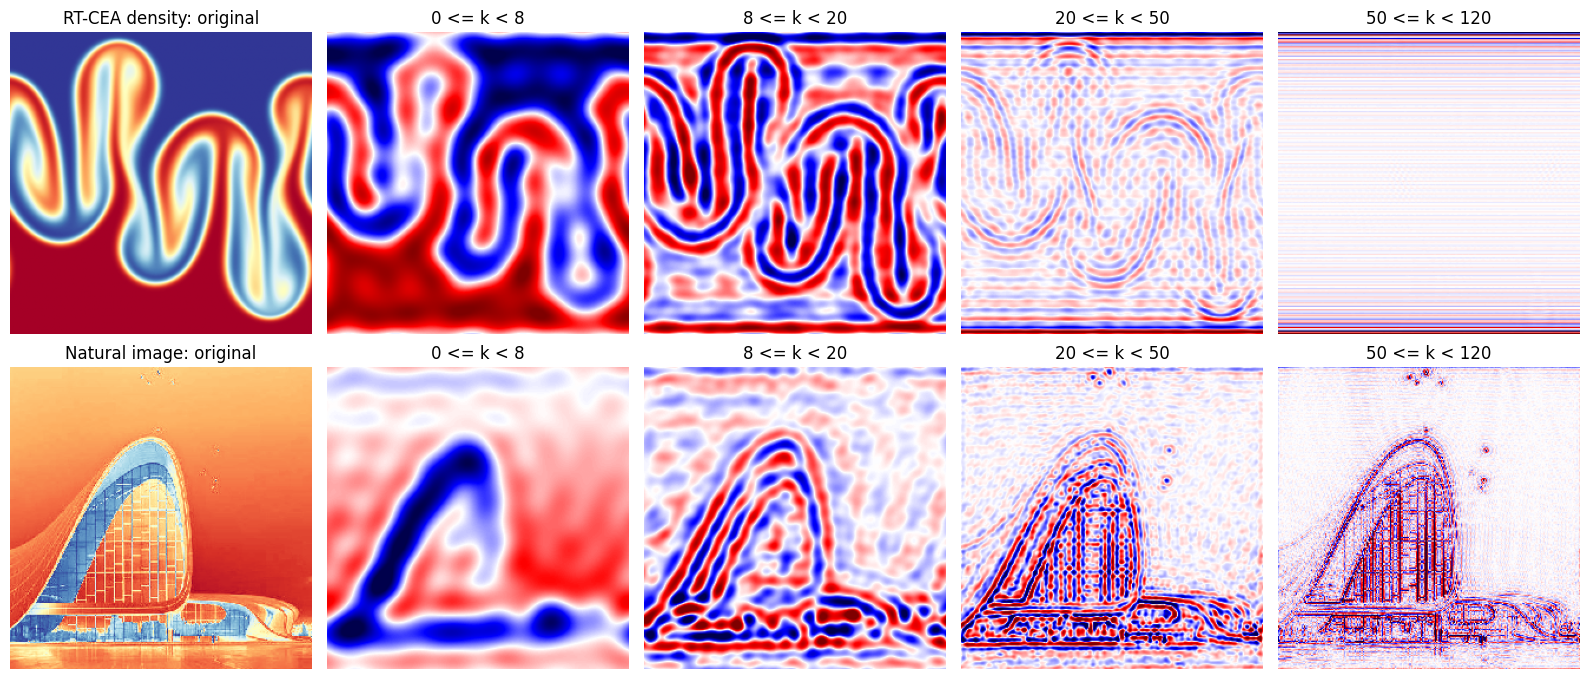

In [9]:
def fourier_bandpass(x, kmin, kmax):
    ny, nx = x.shape
    ky = np.fft.fftfreq(ny) * ny
    kx = np.fft.fftfreq(nx) * nx
    KX, KY = np.meshgrid(kx, ky)
    kr = np.sqrt(KX ** 2 + KY ** 2)
    mask = (kr >= kmin) & (kr < kmax)
    F = np.fft.fft2(x - x.mean())
    return np.real(np.fft.ifft2(F * mask))


bands = [(0, 8), (8, 20), (20, 50), (50, 120)]
fig, ax = plt.subplots(len(comparison_images), len(bands) + 1, figsize=(16, 7))
for row, (name, img) in enumerate(comparison_images):
    ax[row, 0].imshow(img, origin=display_origins[name])
    ax[row, 0].set_title(f"{name}: original")
    ax[row, 0].axis("off")

    for a, (kmin, kmax) in zip(ax[row, 1:], bands):
        xb = fourier_bandpass(img, kmin, kmax)
        vmax = np.percentile(np.abs(xb), 99)
        a.imshow(xb, origin=display_origins[name], cmap="seismic", vmin=-vmax, vmax=vmax)
        a.set_title(f"{kmin} <= k < {kmax}")
        a.axis("off")

plt.tight_layout()
plt.show()


## 6. Reconstructions ondelettes par niveaux de detail

Contrairement aux anneaux Fourier, les niveaux ondelettes localisent les details dans l'espace et en echelle. C'est souvent plus informatif pour la RTI, ou les petites structures sont concentrees dans la zone de melange plutot que distribuees uniformement.

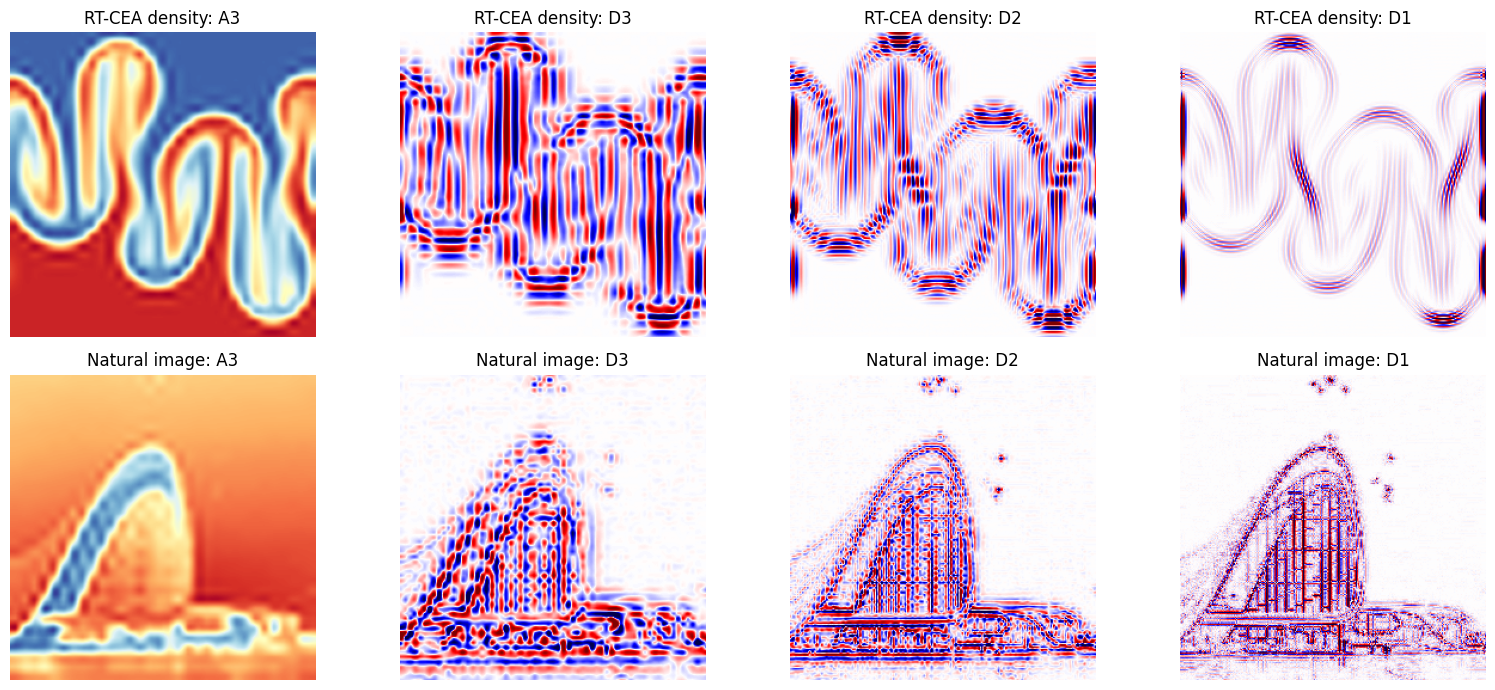

In [10]:
def wavelet_component_reconstructions(x, wavelet="sym6", level=3):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level)
    comps = []

    zero_details = [tuple(np.zeros_like(c) for c in detail) for detail in coeffs[1:]]
    approx_coeffs = [coeffs[0]] + zero_details
    comps.append((f"A{level}", pywt.waverec2(approx_coeffs, wavelet)[:x.shape[0], :x.shape[1]]))

    for idx, ell in enumerate(range(level, 0, -1), start=1):
        coeffs_i = [np.zeros_like(coeffs[0])]
        for j, detail in enumerate(coeffs[1:], start=1):
            if j == idx:
                coeffs_i.append(detail)
            else:
                coeffs_i.append(tuple(np.zeros_like(c) for c in detail))
        rec = pywt.waverec2(coeffs_i, wavelet)[:x.shape[0], :x.shape[1]]
        comps.append((f"D{ell}", rec))
    return comps


rt_components = wavelet_component_reconstructions(x, WAVELET, WAVELET_LEVEL)
component_names = [name for name, _ in rt_components]
fig, ax = plt.subplots(len(comparison_images), len(component_names), figsize=(4 * len(component_names), 7))
for row, (image_name, img) in enumerate(comparison_images):
    components = wavelet_component_reconstructions(img, WAVELET, WAVELET_LEVEL)
    for col, (name, comp) in enumerate(components):
        vmax = np.percentile(np.abs(comp), 99)
        if name.startswith("A"):
            ax[row, col].imshow(comp, origin=display_origins[image_name])
        else:
            ax[row, col].imshow(comp, origin=display_origins[image_name], cmap="seismic", vmin=-vmax, vmax=vmax)
        ax[row, col].set_title(f"{image_name}: {name}")
        ax[row, col].axis("off")

plt.tight_layout()
plt.show()


## 7. Evolution statistique sur quelques snapshots

Cette derniere representation agrege seulement le sous-ensemble charge. Elle permet de voir si la largeur de bande multi-echelle evolue avec le temps. Pour une analyse quantitative finale, augmenter `MAX_SNAPSHOTS` progressivement en surveillant la memoire.

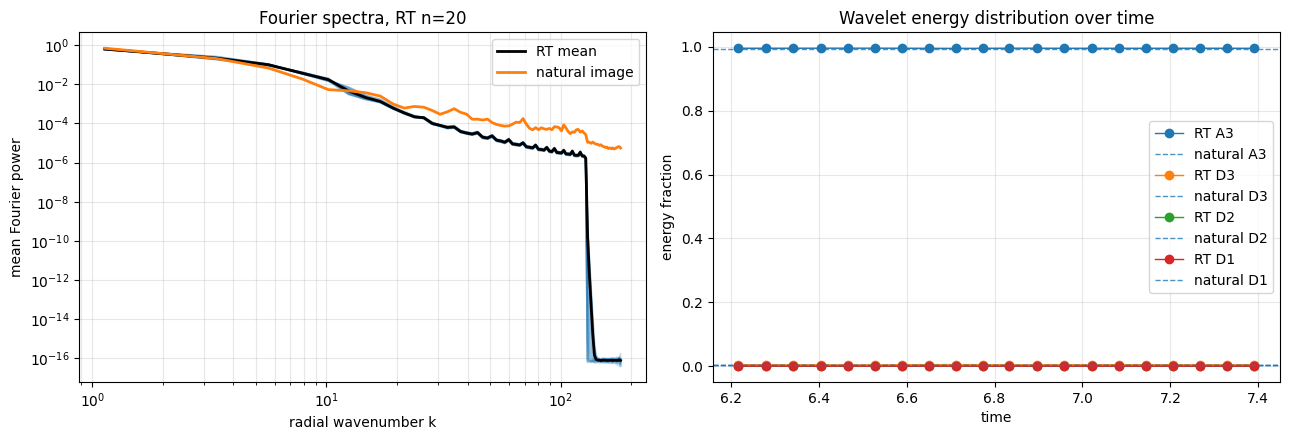

In [11]:
spectra = []
wavelet_fractions = []
for xi in data:
    ki, Ei = radial_power_spectrum(xi, nbins=80)
    spectra.append(Ei / Ei.sum())
    _, wi = wavelet_energy_by_level(xi, WAVELET, WAVELET_LEVEL)
    wavelet_fractions.append(wi / wi.sum())

spectra = np.asarray(spectra)
wavelet_fractions = np.asarray(wavelet_fractions)
times = labels[:, 1]

natural_k, natural_E = radial_power_spectrum(natural_image, nbins=80)
natural_E = natural_E / natural_E.sum()
natural_names, natural_w = wavelet_energy_by_level(natural_image, WAVELET, WAVELET_LEVEL)
natural_fraction = natural_w / natural_w.sum()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

valid = (ki > 0) & np.all(spectra > 0, axis=0)
for i in range(len(data)):
    ax[0].loglog(ki[valid], spectra[i, valid], color="tab:blue", alpha=0.2)
ax[0].loglog(ki[valid], np.mean(spectra[:, valid], axis=0), color="black", lw=2, label="RT mean")
natural_valid = (natural_k > 0) & (natural_E > 0)
ax[0].loglog(natural_k[natural_valid], natural_E[natural_valid], color="tab:orange", lw=2, label="natural image")
ax[0].set_xlabel("radial wavenumber k")
ax[0].set_ylabel("mean Fourier power")
ax[0].set_title(f"Fourier spectra, RT n={len(data)}")
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

for j, name in enumerate(names):
    ax[1].plot(times, wavelet_fractions[:, j], marker="o", lw=1, label=f"RT {name}")
    ax[1].axhline(natural_fraction[j], ls="--", lw=1, alpha=0.8, label=f"natural {name}")
ax[1].set_xlabel("time")
ax[1].set_ylabel("energy fraction")
ax[1].set_title("Wavelet energy distribution over time")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Interpretation possible pour le rapport

Ces visualisations ne prouvent pas a elles seules une loi d'echelle universelle. Elles montrent cependant trois faits robustes pour le dataset RT-CEA: l'energie n'est pas concentree dans une unique frequence, les details fins sont spatialement localises dans la zone de melange, et les contributions ondelettes restent reparties sur plusieurs niveaux. Cela justifie l'interet d'une representation multi-resolution, notamment pour comparer un modele de diffusion en espace image et un modele fonde sur une decomposition en ondelettes.